In [62]:
import numpy as np
from numpy import pi, log, linspace
from utils import e_r_cpa_numerator, e_r_cpa_denominator, e_r_cpa, h_r_cpa_numerator, h_r_cpa, hl2, hl2prime
import matplotlib.pyplot as plt

### In this notebook, we recreate Figure 1 of the following paper: [Completeness and time-independent perturbation of morphology-dependent resonances in dielectric spheres](https://opg.optica.org/josab/fulltext.cfm?uri=josab-13-5-805)

In [7]:
n = 1.33
omega_imag_asymptotic = -1/(2*n)*log((n+1)/(n-1))

In [177]:
N = 2000
M = 2000
x_real = linspace(-1, 40, N)
x_imag = linspace(-8, -0.1, M)
x = x_real.reshape((N, 1)).repeat(M, axis=1) + 1j*x_imag.reshape((1, M)).repeat(N, axis=0)
l = 10
s_arr_tm = e_r_cpa(l, x, n**2)
s_arr_te = h_r_cpa(l, x, n**2)

In [189]:
#fig, ax = plt.subplots(figsize=(10, 10))
#ax.contourf(log((np.abs(s_arr_tm)**2).T), origin="lower", cmap="hot", vmin=5);
#ax.contourf(log((np.abs(s_arr_te)**2).T), origin="lower", cmap="hot", vmin=2);

In [190]:
tm_resonances = x[np.where(log((np.abs(s_arr_tm)**2)) > 6)]
te_resonances = x[np.where(log((np.abs(s_arr_te)**2)) > 6)];

In [193]:
#plt.scatter(tm_resonances.real, tm_resonances.imag)
#plt.scatter(te_resonances.real, te_resonances.imag, color="red");

In [191]:
filtered_tm_resonances_real = []
filtered_tm_resonances_imag = []

filtered_te_resonances_real = []
filtered_te_resonances_imag = []

filtered_tm_resonances_real.append(tm_resonances.real[0])
filtered_tm_resonances_imag.append(tm_resonances.imag[0])

filtered_te_resonances_real.append(te_resonances.real[0])
filtered_te_resonances_imag.append(te_resonances.imag[0])

for (r, i) in zip(tm_resonances.real[1:], tm_resonances.imag[1:]):
    filter_out = 0
    for (r_filtered, i_filtered) in zip(filtered_tm_resonances_real, filtered_tm_resonances_imag):
        if (r-r_filtered)**2+(i-i_filtered)**2<0.15**2:
            filter_out += 1
            continue
    if filter_out > 0:
        continue
    filtered_tm_resonances_real.append(r)
    filtered_tm_resonances_imag.append(i)

for (r, i) in zip(te_resonances.real[1:], te_resonances.imag[1:]):
    filter_out = 0
    for (r_filtered, i_filtered) in zip(filtered_te_resonances_real, filtered_te_resonances_imag):
        if (r-r_filtered)**2+(i-i_filtered)**2<0.15**2:
            filter_out += 1
            continue
    if filter_out > 0:
        continue
    filtered_te_resonances_real.append(r)
    filtered_te_resonances_imag.append(i)

In [213]:
#plt.scatter(filtered_tm_resonances_real, filtered_tm_resonances_imag, s=100, color="black")
#plt.scatter(filtered_te_resonances_real, filtered_te_resonances_imag, s=100, color="red")
#plt.hlines([omega_imag_asymptotic], -10, 50, color="green", linestyle="dotted")
#plt.xlim(0, 40)
#plt.ylim(-8, 0);

### Now we do a finer mesh centered around each resonance

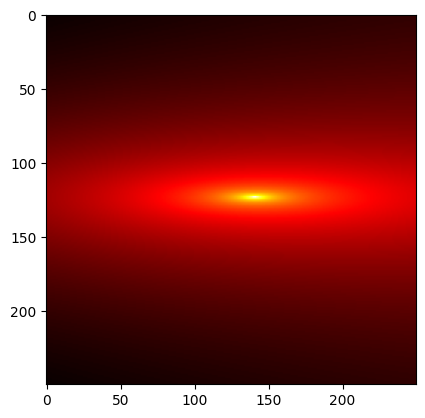

(-0.006024096385542188+0.013253012048192403j)


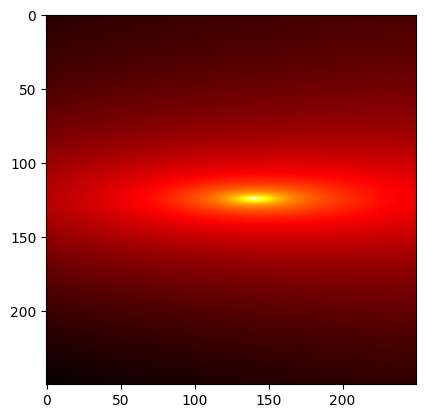

(-0.002008032128514081+0.013253012048192403j)


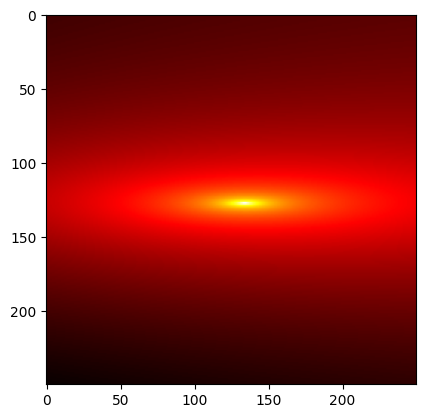

(0.010040160642570406+0.007630522088353686j)


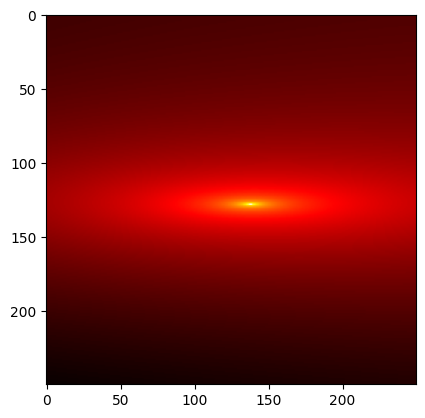

(0.014056224899598568+0.010843373493975683j)


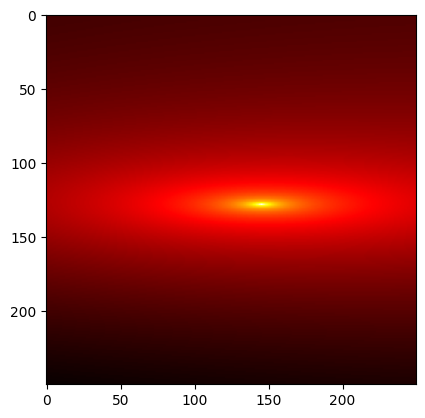

(0.014056224899598568+0.016465863453815288j)


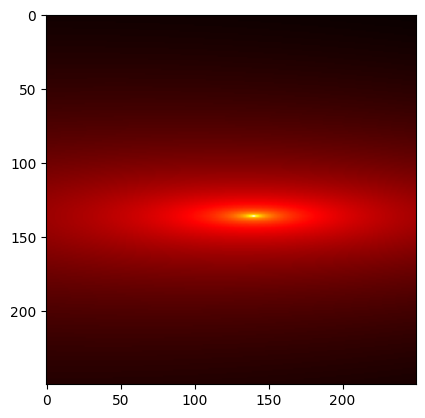

(0.04618473895582298+0.012449799196787126j)


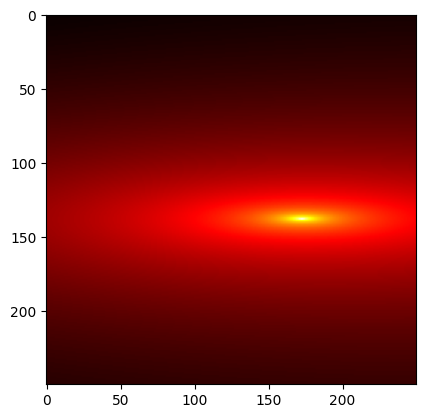

(0.054216867469879304+0.0381526104417671j)


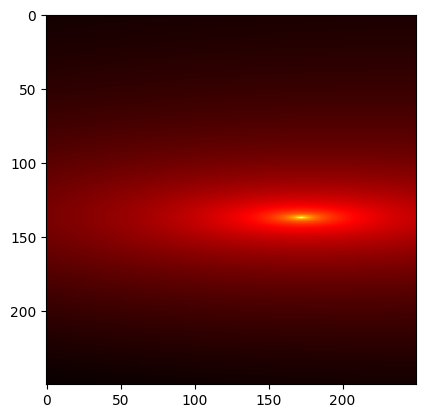

(0.05020080321285114+0.0381526104417671j)


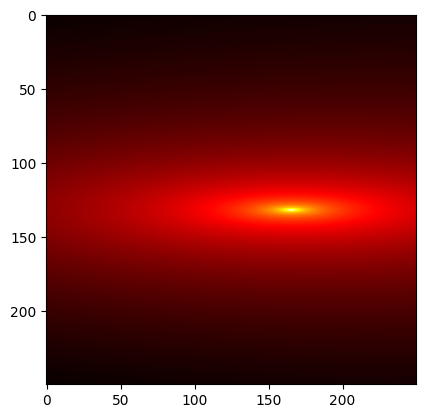

(0.03012048192771033+0.032530120481927716j)


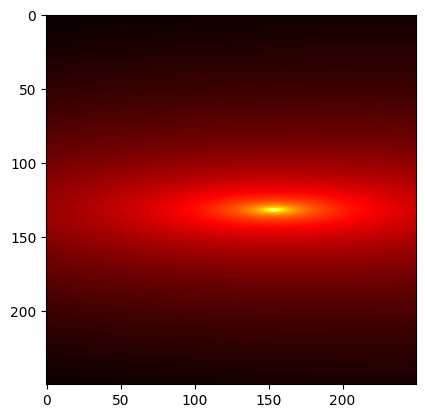

(0.03012048192771033+0.02369477911646578j)


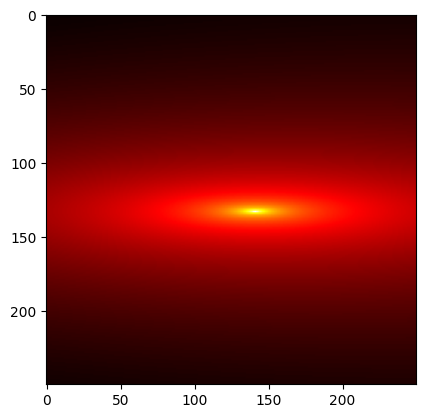

(0.03413654618474027+0.013253012048192736j)


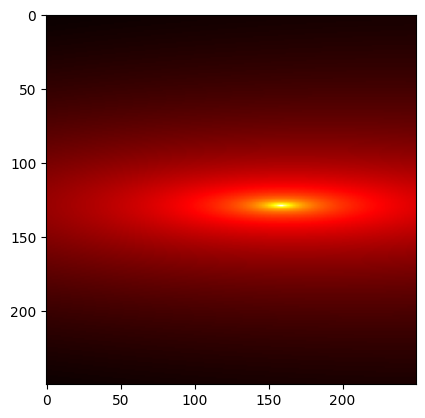

(0.01807228915662762+0.026907630522088333j)


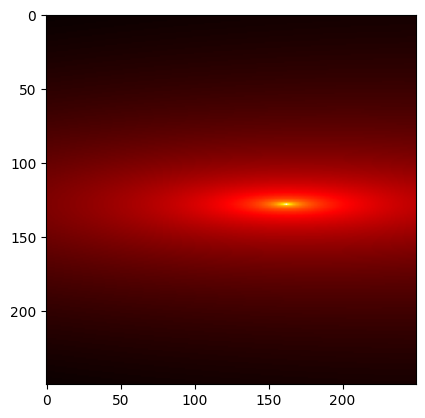

(0.01405622489959768+0.030120481927710774j)


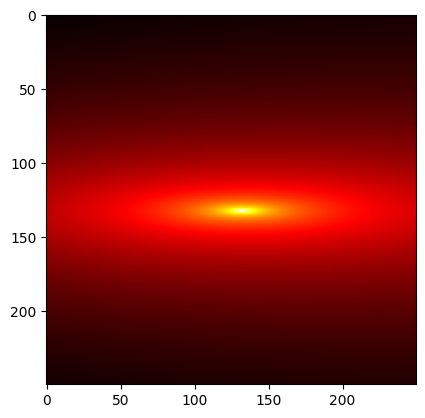

(0.03012048192771033+0.0060240963855421326j)


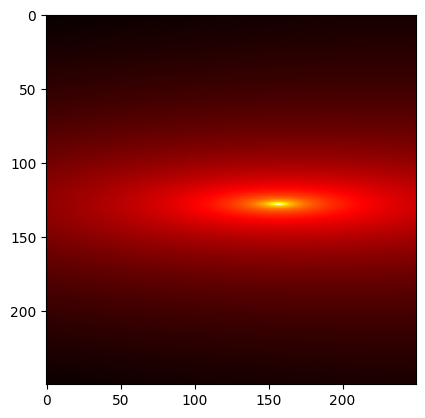

(0.01405622489959768+0.025301204819277112j)


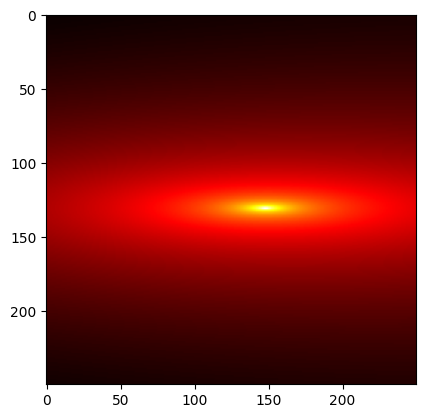

(0.02610441767068039+0.01887550200803212j)


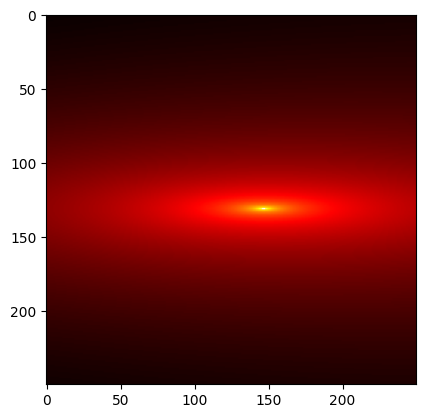

(0.02610441767068039+0.01807228915662651j)


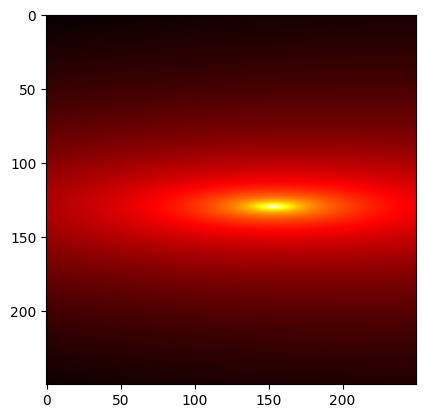

(0.01807228915662762+0.02289156626506028j)


In [209]:
zoomed_tm_resonances_real = []
zoomed_tm_resonances_imag = []

N_prime = 250
M_prime = 250
for (r, i) in zip(filtered_tm_resonances_real, filtered_tm_resonances_imag):
    x_real = linspace(r-0.5, r+0.5, N_prime)
    x_imag = linspace(i-0.1, i+0.1, M_prime)
    x = x_real.reshape((N_prime, 1)).repeat(M_prime, axis=1) + 1j*x_imag.reshape((1, M_prime)).repeat(N_prime, axis=0)
    s_arr_tm = e_r_cpa(l, x, n**2)
    plt.imshow(log(np.abs(s_arr_tm)**2), cmap="hot")
    plt.show()
    best_x = x.flatten()[(np.abs(s_arr_tm)**2).argmax()]
    print(best_x - (r+1j*i))
    zoomed_tm_resonances_real.append(best_x.real)
    zoomed_tm_resonances_imag.append(best_x.imag)

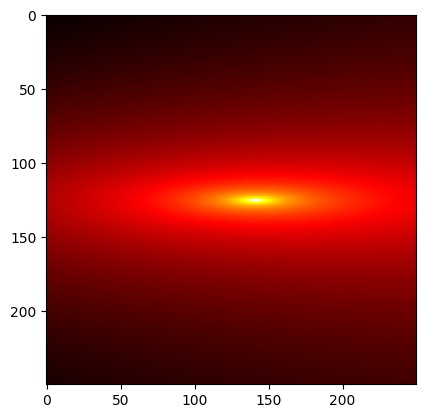

(0.00200803212851397+0.013253012048192403j)


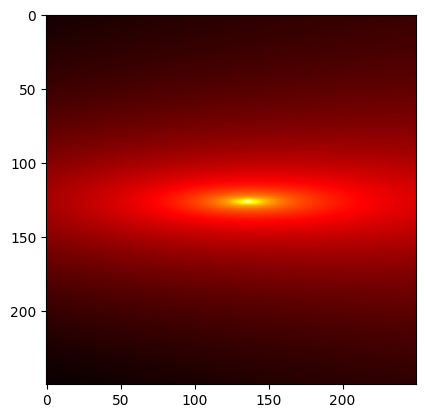

(0.0060240963855421326+0.00923694779116424j)


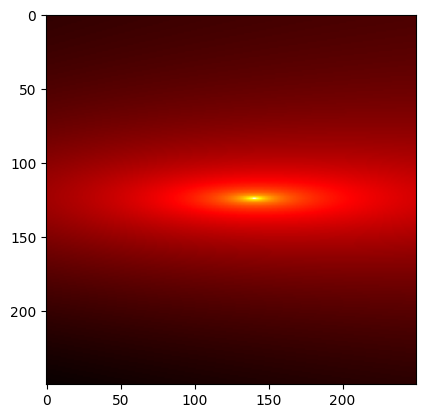

(-0.002008032128514081+0.012449799196787126j)


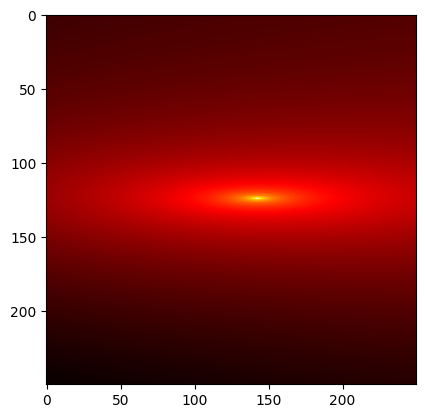

(-0.002008032128514081+0.014056224899598568j)


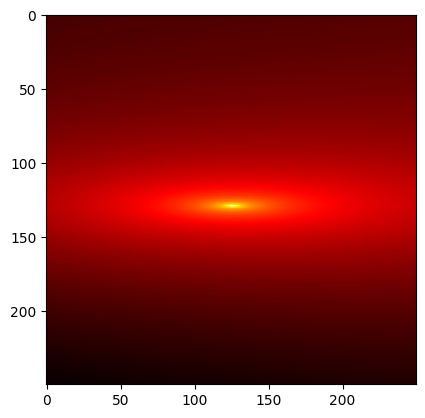

(0.01807228915662673+0.0004016064257026386j)


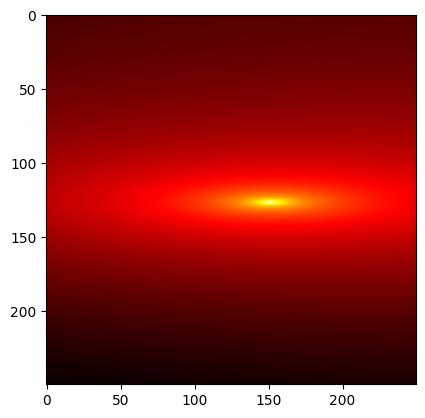

(0.010040160642569518+0.021285140562248728j)


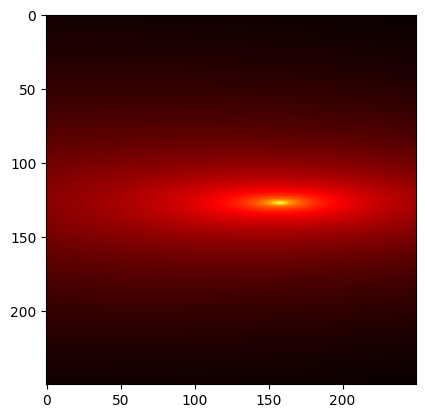

(0.010040160642569518+0.026104417670682722j)


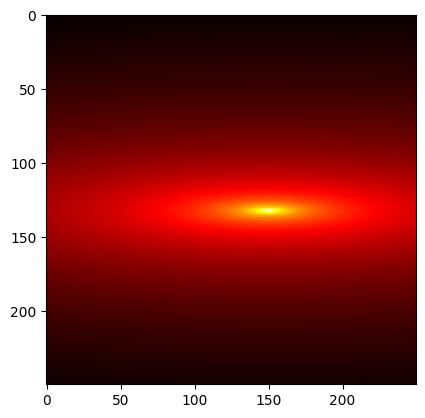

(0.03012048192771033+0.02048192771084334j)


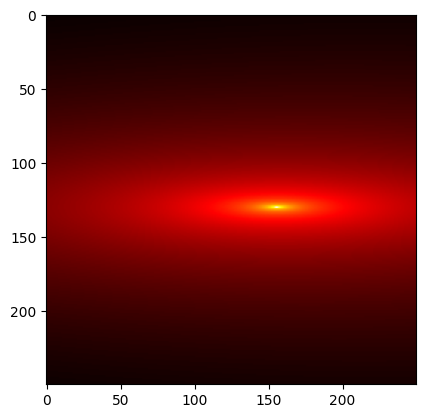

(0.022088353413654005+0.024497991967871502j)


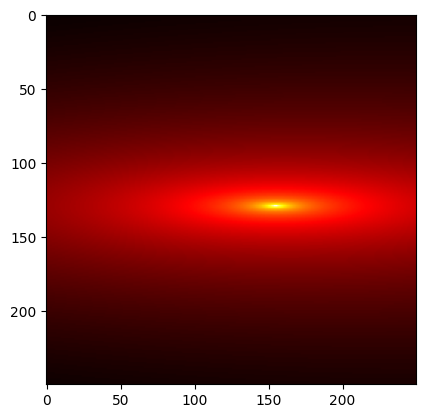

(0.01807228915662762+0.024497991967871502j)


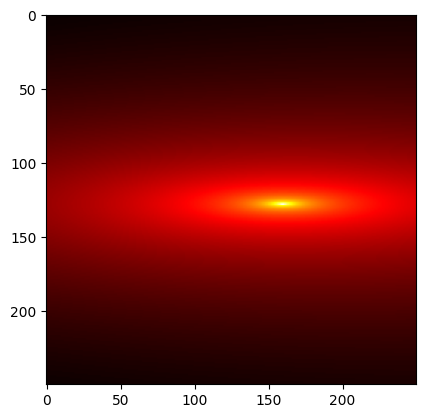

(0.01405622489959768+0.027710843373493943j)


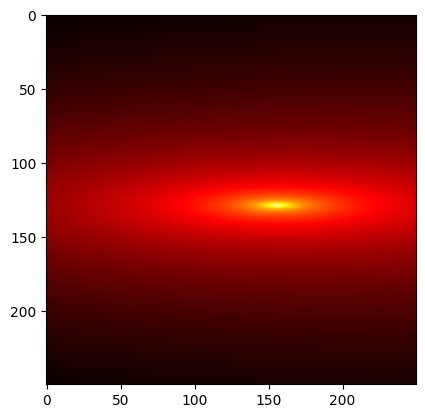

(0.01807228915662762+0.025301204819277112j)


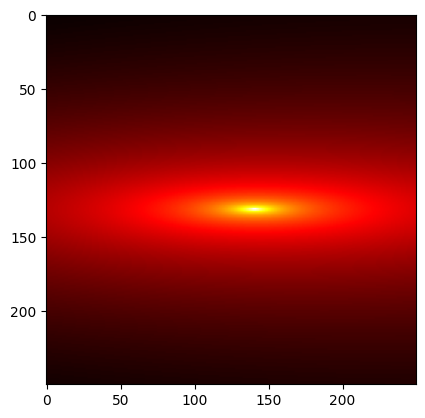

(0.026104417670683944+0.012449799196787126j)


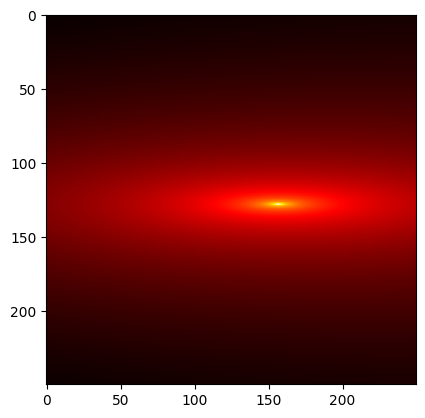

(0.01405622489959768+0.025301204819277112j)


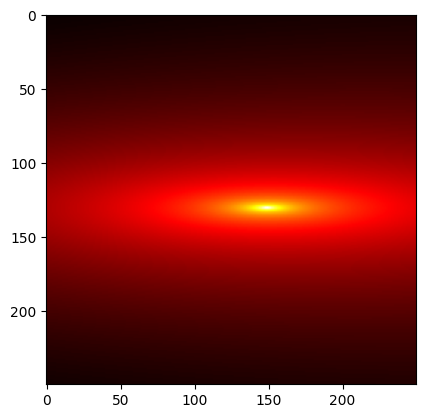

(0.022088353413654005+0.01967871485943773j)


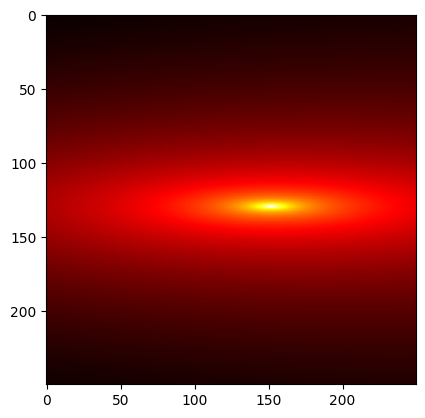

(0.01807228915662762+0.02208835341365467j)


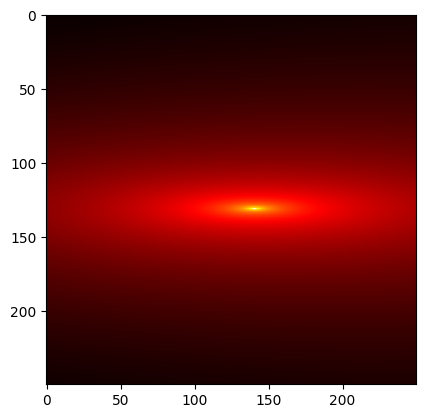

(0.02610441767068039+0.012449799196787126j)


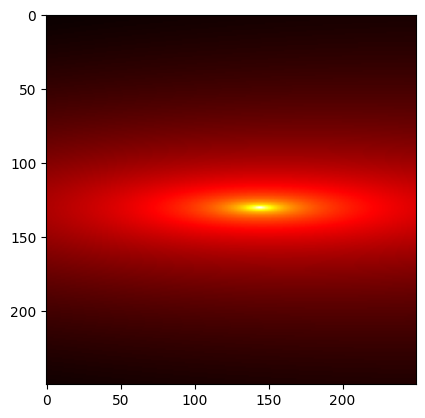

(0.022088353413657558+0.015662650602409678j)


In [214]:
zoomed_te_resonances_real = []
zoomed_te_resonances_imag = []

N_prime = 250
M_prime = 250
for (r, i) in zip(filtered_te_resonances_real, filtered_te_resonances_imag):
    x_real = linspace(r-0.5, r+0.5, N_prime)
    x_imag = linspace(i-0.1, i+0.1, M_prime)
    x = x_real.reshape((N_prime, 1)).repeat(M_prime, axis=1) + 1j*x_imag.reshape((1, M_prime)).repeat(N_prime, axis=0)
    s_arr_te = h_r_cpa(l, x, n**2)
    plt.imshow(log(np.abs(s_arr_te)**2), cmap="hot")
    plt.show()
    best_x = x.flatten()[(np.abs(s_arr_te)**2).argmax()]
    print(best_x - (r+1j*i))
    zoomed_te_resonances_real.append(best_x.real)
    zoomed_te_resonances_imag.append(best_x.imag)

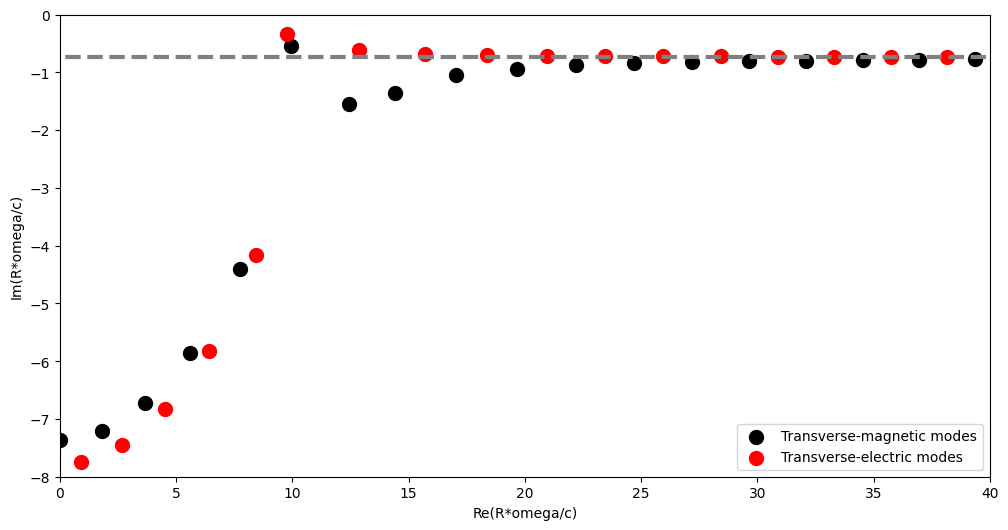

In [229]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.scatter(zoomed_tm_resonances_real, zoomed_tm_resonances_imag, color="black", s=100, label="Transverse-magnetic modes")
ax.scatter(zoomed_te_resonances_real, zoomed_te_resonances_imag, color="red", s=100, label="Transverse-electric modes");
ax.hlines([omega_imag_asymptotic], -10, 50, color="Gray", linestyle="dashed", linewidth=3)
ax.set_xlim(0, 40); plt.ylim(-8, 0);
ax.legend();
ax.set_xlabel("Re(R*omega/c)")
ax.set_ylabel("Im(R*omega/c)");